# VTU to VTU Registration — ANTsPy SyNRA
> Both fixed and moving are `.vtu` meshes. No `.nii.gz` needed.

| Cell | Stage |
|------|-------|
| 1 | Install |
| 2 | Config |
| 3 | Load both VTU + voxelize |
| 4 | ANTsPy SyNRA registration |
| 4b | Overlay visualisation |
| 5 | Apply warp to mesh nodes -> new `.vtu` |
| 6 | Validate + output summary |

**SyNRA** = Rigid + Affine + SyN diffeomorphic warp — gold standard for anatomical registration.
The displacement field is applied directly to mesh node coordinates via `ants.apply_transforms_to_points()`.


In [1]:
pip install antspyx pyvista numpy matplotlib SimpleITK pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 17.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [pyvista]m5/6 [pyvista]]
Note: you may need to restart the kernel to use updated packages.


In [6]:
import os

export_folder = '/Users/lapastang/Downloads/case01'

print("Files in folder:")
for f in sorted(os.listdir(export_folder)):
    full = os.path.join(export_folder, f)
    size = os.path.getsize(full) / 1e6
    print(f"  {f:<60} {size:.1f} MB")

Files in folder:
  After_Affine_Refinement.png                                  0.3 MB
  After_Center_Alignment.png                                   0.3 MB
  After_Rigid_Registration.png                                 0.3 MB
  ct_preprocessed.nii.gz                                       7.2 MB
  ct_resampled.nii.gz                                          7.2 MB
  mesh_affine.nii.gz                                           259.0 MB
  mesh_center_aligned.nii.gz                                   235.3 MB
  mesh_deformable_final.nii.gz                                 12.7 MB
  mesh_preprocessed.nii.gz                                     309.1 MB
  mesh_rigid.nii.gz                                            258.4 MB
  mesh_voxelized.nii.gz                                        609.5 MB


In [7]:
!pip install antspyx pyvista numpy matplotlib SimpleITK pandas -q

import ants
import pyvista as pv
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pandas as pd
import os, time

print(f'ants    : {ants.__version__}')
print(f'pyvista : {pv.__version__}')
print(f'numpy   : {np.__version__}')


/opt/homebrew/anaconda3/envs/3D/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ants    : 0.6.3
pyvista : 0.48.4
numpy   : 1.26.4


## Cell 2 — Config

In [8]:
# USER EDIT
FIXED_VTU  = r'/Users/lapastang/Downloads/ImageToStl.com_head_voxels_transform.vtu'
MOVING_VTU = r'/Users/lapastang/Downloads/Head_V6.vtu'
OUTPUT_DIR = r'/Users/lapastang/Downloads/case01'

VOXEL_SIZE_MM = 1.0
SYN_TYPE      = 'SyNRA'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
stem = os.path.splitext(os.path.basename(MOVING_VTU))[0]

print(f'Fixed  exists: {os.path.exists(FIXED_VTU)}')
print(f'Moving exists: {os.path.exists(MOVING_VTU)}')
print(f'Output : {OUTPUT_DIR}')
print(f'Method : {SYN_TYPE}')


Fixed  exists: True
Moving exists: True
Output : /Users/lapastang/Downloads/case01
Method : SyNRA


## Cell 3 — Load Both VTU + Voxelize

Converts both meshes to voxel volumes for ANTsPy.
- **Auto-scale**: detects mm vs m unit mismatch and corrects it
- **Gaussian blur**: softens binary volumes so SyN has smooth gradients to follow
- **Margin**: pads bounding box so mesh is not clipped at volume edge


In [28]:
import vtk
import numpy as np
from vtk.util.numpy_support import vtk_to_numpy, numpy_to_vtk

def recentre_vtu(input_path, output_path, target_centre=None):
    """
    Translates a VTU mesh so its centre of mass sits at target_centre.
    Default target_centre = [0, 0, 0]
    """
    reader = vtk.vtkXMLUnstructuredGridReader()
    reader.SetFileName(input_path)
    reader.Update()
    mesh = reader.GetOutput()

    # Get all point coordinates
    pts_vtk = mesh.GetPoints()
    pts = vtk_to_numpy(pts_vtk.GetData())

    current_centre = pts.mean(axis=0)
    if target_centre is None:
        target_centre = np.array([0.0, 0.0, 0.0])

    translation = np.array(target_centre) - current_centre
    pts_new = pts + translation

    print(f"Translating by: {translation}")
    print(f"Old centre: {current_centre}")
    print(f"New centre: {pts_new.mean(axis=0)}")

    # Write back
    new_pts = vtk.vtkPoints()
    new_pts.SetData(numpy_to_vtk(pts_new.astype(np.float32)))
    mesh.SetPoints(new_pts)

    writer = vtk.vtkXMLUnstructuredGridWriter()
    writer.SetFileName(output_path)
    writer.SetInputData(mesh)
    writer.Write()
    print(f"Saved: {output_path}")
    return pts_new.mean(axis=0)


def rescale_vtu(input_path, output_path, scale_factor):
    """
    Scales a VTU mesh by scale_factor around its own centre.
    Use when units differ between fixed and moving.
    """
    reader = vtk.vtkXMLUnstructuredGridReader()
    reader.SetFileName(input_path)
    reader.Update()
    mesh = reader.GetOutput()

    pts = vtk_to_numpy(mesh.GetPoints().GetData())
    centre = pts.mean(axis=0)

    # Scale around centre
    pts_scaled = (pts - centre) * scale_factor + centre

    new_pts = vtk.vtkPoints()
    new_pts.SetData(numpy_to_vtk(pts_scaled.astype(np.float32)))
    mesh.SetPoints(new_pts)

    writer = vtk.vtkXMLUnstructuredGridWriter()
    writer.SetFileName(output_path)
    writer.SetInputData(mesh)
    writer.Write()
    print(f"Scaled by {scale_factor:.4f}, saved: {output_path}")


# ── Step 1: Check scale ───────────────────────────────────────────
# Fixed extent:  [173, 254, 227] mm  ← reasonable head size
# Moving extent: [231, 165, 252] mm  ← also reasonable
# Scale ratio: [0.75, 1.54, 0.90]
# The Y axis ratio (1.54) is the problem — likely a flipped axis

# ── Step 2: Recentre both to origin ──────────────────────────────
recentre_vtu(
    "/Users/lapastang/Downloads/ImageToStl.com_head_voxels_transform.vtu",          # your actual fixed path
    "outputs/synra/fixed_centred.vtu",
    
    target_centre=[0.0, 0.0, 0.0]
)

recentre_vtu(
    "/Users/lapastang/Downloads/Head_V6.vtu",  # your actual moving path
    "outputs/synra/moving_centred.vtu",
    target_centre=[0.0, 0.0, 0.0]
)

# ── Step 3: Check Y scale mismatch ───────────────────────────────
# Fixed Y extent:  254mm
# Moving Y extent: 165mm
# Ratio: 1.54 — the skull is too short in Y
# This might be a real shape difference OR an axis assignment problem

# Check if moving needs Y scaling to match fixed
fixed_extent  = np.array([173., 254., 227.])
moving_extent = np.array([231., 165., 252.])
scale_per_axis = fixed_extent / moving_extent
print(f"Per-axis scale needed: {scale_per_axis}")
# If one axis is very different from others, it is likely a flip not a scale

2026-06-29 20:15:53.139 (13455.721s) [          FDC351]       vtkXMLWriter.cxx:634    ERR| vtkXMLUnstructuredGridWriter (0x323f79ae0): Error opening output file "outputs/synra/fixed_centred.vtu"
ERROR:root:Error opening output file "outputs/synra/fixed_centred.vtu"
ERROR:root:Error code "Resource temporarily unavailable"
2026-06-29 20:15:53.140 (13455.723s) [          FDC351]       vtkXMLWriter.cxx:637    ERR| vtkXMLUnstructuredGridWriter (0x323f79ae0): Error code "Resource temporarily unavailable"
2026-06-29 20:15:53.141 (13455.723s) [          FDC351]       vtkExecutive.cxx:730    ERR| vtkCompositeDataPipeline (0x323f7b900): Algorithm vtkXMLUnstructuredGridWriter (0x323f79ae0) returned failure for request: vtkInformation (0x323f7c300)
  Debug: Off
  Modified Time: 16912
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: -1
  ALGORITHM_AFTER_FORWARD: 1
  FORWARD_DIRECTION: 0


ERROR:root:Algorithm vtkXMLUnstructuredGridWriter (0x323f79ae0) ret

Translating by: [ -83.15765381 -130.90748596 -115.42295837]
Old centre: [ 83.15765 130.90749 115.42296]
New centre: [0.01912366 0.05039267 0.06514656]
Saved: outputs/synra/fixed_centred.vtu
Translating by: [-0.10482948 -0.04219674 -0.05878096]
Old centre: [0.10482948 0.04219674 0.05878096]
New centre: [-0.08570581  0.00819593  0.0063656 ]
Saved: outputs/synra/moving_centred.vtu
Per-axis scale needed: [0.74891775 1.53939394 0.90079365]


In [29]:
def load_vtu(path):
    mesh  = pv.read(path)
    nodes = np.array(mesh.points, dtype=np.float64)
    print(f'  Points   : {len(nodes):,}')
    print(f'  Cells    : {mesh.n_cells:,}')
    print(f'  Centroid : {nodes.mean(axis=0).round(2)}')
    print(f'  Extent X : [{nodes[:,0].min():.2f}, {nodes[:,0].max():.2f}]  range={nodes[:,0].ptp():.2f}')
    print(f'  Extent Y : [{nodes[:,1].min():.2f}, {nodes[:,1].max():.2f}]  range={nodes[:,1].ptp():.2f}')
    print(f'  Extent Z : [{nodes[:,2].min():.2f}, {nodes[:,2].max():.2f}]  range={nodes[:,2].ptp():.2f}')
    return mesh, nodes


def normalize_to_shared_space(nodes_fixed, nodes_moving):
    """
    1. Centroid align — move both meshes to origin so coordinate offsets cancel.
    2. Scale align    — rescale moving so its extent matches fixed.
    This is mandatory when fixed (STL surface) and moving (FEM volume)
    live in completely different coordinate spaces.
    """
    # Step 1: remove centroid offset from both
    c_fixed  = nodes_fixed.mean(axis=0)
    c_moving = nodes_moving.mean(axis=0)
    nf = nodes_fixed  - c_fixed
    nm = nodes_moving - c_moving
    print(f'  Removed fixed  centroid: {c_fixed.round(2)}')
    print(f'  Removed moving centroid: {c_moving.round(2)}')

    # Step 2: scale moving to match fixed bounding box
    ext_f  = nf.max(axis=0) - nf.min(axis=0)
    ext_m  = nm.max(axis=0) - nm.min(axis=0)
    ratios = ext_f / (ext_m + 1e-8)
    scale  = float(np.median(ratios))
    print(f'  Fixed  extent : {ext_f.round(2)}')
    print(f'  Moving extent : {ext_m.round(2)}')
    print(f'  Scale factor  : {scale:.4f}')
    nm_scaled = nm * scale
    print(f'  Moving extent after scale: {(nm_scaled.max(axis=0)-nm_scaled.min(axis=0)).round(2)}')
    return nf, nm_scaled, scale, c_fixed, c_moving


def voxelize_shared(nodes, shared_mins, shared_maxs,
                    voxel_size=1.0, sigma=3.0, tmp_path=None):
    """
    Voxelize onto a FIXED shared grid.
    Both fixed and moving MUST use the same shared_mins/maxs
    so ANTsPy gets two images with identical size, spacing, and origin.
    """
    dims = np.ceil((shared_maxs - shared_mins) / voxel_size).astype(int)
    vol  = np.zeros(dims[::-1], dtype=np.float32)
    idx  = np.clip(
        np.floor((nodes - shared_mins) / voxel_size).astype(int),
        0, dims - 1
    )
    vol[idx[:,2], idx[:,1], idx[:,0]] = 1.0
    sitk_img = sitk.GetImageFromArray(vol)
    sitk_img.SetSpacing([voxel_size]*3)
    sitk_img.SetOrigin(shared_mins.tolist())
    if sigma > 0:
        sitk_img = sitk.SmoothingRecursiveGaussian(sitk_img, sigma=sigma)
    sitk.WriteImage(sitk_img, tmp_path)
    return ants.image_read(tmp_path)


# Load
print('Loading FIXED VTU...')
fixed_mesh,  nodes_fixed  = load_vtu(FIXED_VTU)
print('\nLoading MOVING VTU...')
moving_mesh, nodes_moving = load_vtu(MOVING_VTU)

# Normalize both to shared coordinate space
print('\nNormalizing to shared space...')
nodes_fixed_norm, nodes_moving_norm, scale_factor, c_fixed, c_moving = \
    normalize_to_shared_space(nodes_fixed, nodes_moving)

# Verify overlap after normalization
print('\nPost-normalization extents (should overlap):')
print(f'  Fixed  X: [{nodes_fixed_norm[:,0].min():.2f}, {nodes_fixed_norm[:,0].max():.2f}]')
print(f'  Moving X: [{nodes_moving_norm[:,0].min():.2f}, {nodes_moving_norm[:,0].max():.2f}]')
print(f'  Fixed  Y: [{nodes_fixed_norm[:,1].min():.2f}, {nodes_fixed_norm[:,1].max():.2f}]')
print(f'  Moving Y: [{nodes_moving_norm[:,1].min():.2f}, {nodes_moving_norm[:,1].max():.2f}]')

# Build shared bounding box from BOTH meshes together
all_nodes   = np.vstack([nodes_fixed_norm, nodes_moving_norm])
shared_mins = all_nodes.min(axis=0) - 15.0
shared_maxs = all_nodes.max(axis=0) + 15.0

# Voxelize both onto the same grid
print(f'\nVoxelizing at {VOXEL_SIZE_MM} mm on shared grid...')
fixed_ants = voxelize_shared(
    nodes_fixed_norm, shared_mins, shared_maxs,
    voxel_size=VOXEL_SIZE_MM, sigma=3.0,
    tmp_path=os.path.join(OUTPUT_DIR, 'fixed_voxelized.nii.gz')
)
moving_ants = voxelize_shared(
    nodes_moving_norm, shared_mins, shared_maxs,
    voxel_size=VOXEL_SIZE_MM, sigma=3.0,
    tmp_path=os.path.join(OUTPUT_DIR, 'moving_voxelized.nii.gz')
)

print(f'Fixed  ANTs : {fixed_ants.shape}  origin={[round(o,1) for o in fixed_ants.origin]}')
print(f'Moving ANTs : {moving_ants.shape}  origin={[round(o,1) for o in moving_ants.origin]}')
print(f'Grid match  : {fixed_ants.shape == moving_ants.shape}  <- must be True')
print('Voxelization complete.')


Loading FIXED VTU...
  Points   : 405,210
  Cells    : 816,040
  Centroid : [ 83.18 130.96 115.49]
  Extent X : [-0.50, 172.50]  range=173.00
  Extent Y : [-0.50, 253.50]  range=254.00
  Extent Z : [-0.50, 226.50]  range=227.00

Loading MOVING VTU...
  Points   : 405,210
  Cells    : 816,040
  Centroid : [0.02 0.05 0.07]
  Extent X : [-83.66, 89.34]  range=173.00
  Extent Y : [-131.41, 122.59]  range=254.00
  Extent Z : [-115.92, 111.08]  range=227.00

Normalizing to shared space...
  Removed fixed  centroid: [ 83.18 130.96 115.49]
  Removed moving centroid: [0.02 0.05 0.07]
  Fixed  extent : [173. 254. 227.]
  Moving extent : [173. 254. 227.]
  Scale factor  : 1.0000
  Moving extent after scale: [173. 254. 227.]

Post-normalization extents (should overlap):
  Fixed  X: [-83.68, 89.32]
  Moving X: [-83.68, 89.32]
  Fixed  Y: [-131.46, 122.54]
  Moving Y: [-131.46, 122.54]

Voxelizing at 1.0 mm on shared grid...
Fixed  ANTs : (203, 284, 257)  origin=[-98.7, -146.5, -131.0]
Moving ANTs :

## Cell 4 — ANTsPy SyNRA Registration

`SyNRA` runs three stages internally:
1. **Rigid** — rotation + translation (6 DOF)
2. **Affine** — + scale + shear (12 DOF)
3. **SyN** — diffeomorphic non-linear warp field

The output is a composite transform: `[warp_field.nii.gz, affine.mat]`


In [30]:
print(f'Running ANTsPy {SYN_TYPE} registration...')
print('This may take 2-5 minutes.\n')
t0 = time.time()

result = ants.registration(
    fixed   = fixed_ants,
    moving  = moving_ants,
    type_of_transform = SYN_TYPE,

    # Metric: meansquares works far better than MI on binary/sparse volumes
    syn_metric     = 'meansquares',
    syn_sampling   = 0.5,

    # Iterations per resolution level (coarse -> fine)
    # Increase first number if registration is not converging
    reg_iterations = (200, 100, 50),

    # Regularization: higher flow_sigma = smoother, less local warp
    # For rigid head shapes: 3.0 is a good starting point
    flow_sigma     = 3,
    total_sigma    = 0,

    # Affine stage settings
    aff_metric     = 'meansquares',
    aff_sampling   = 32,
    aff_iterations = (2100, 1200, 200, 0),

    grad_step      = 0.1,
    verbose        = True,
)

elapsed = time.time() - t0
print(f'\nDone in {elapsed:.1f}s ({elapsed/60:.1f} min)')
print('\nTransform files:')
for tf in result['fwdtransforms']:
    print(f'  {tf}')

# Save warped volume
warped_path = os.path.join(OUTPUT_DIR, 'moving_warped_synra.nii.gz')
ants.image_write(result['warpedmovout'], warped_path)
print(f'\nWarped volume -> {warped_path}')


Running ANTsPy SyNRA registration...
This may take 2-5 minutes.

antsRegistration --dimensionality 3 -r [0x1741d1948,0x345993908,1] --metric meansquares[0x1741d1948,0x345993908,1,32,regular,0.2] --transform Rigid[0.25] --convergence 2100x1200x1200x0 --smoothing-sigmas 3x2x1x0 --shrink-factors 4x2x2x1 -x [NA,NA] --metric meansquares[0x1741d1948,0x345993908,1,32,regular,0.2] --transform Affine[0.25] --convergence 2100x1200x1200x0 --smoothing-sigmas 3x2x1x0 --shrink-factors 4x2x2x1 -x [NA,NA] --metric meansquares[0x1741d1948,0x345993908,1,0.5] --transform SyN[0.100000,3.000000,0.000000] --convergence [200x100x50,1e-7,8] --smoothing-sigmas 2x1x0 --shrink-factors 4x2x1 -u 0 -z 1 --output [/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/tmp9v60pv3e,0x349c1b9c8,0x349c1bca8] -x [NA,NA] --float 1 --write-composite-transform 0 -v 1
All_Command_lines_OK
Using single precision for computations.
The composite transform comprises the following transforms (in order): 
  1. Center of mass alignment u

## Cell 4b — Visualise Registration Result

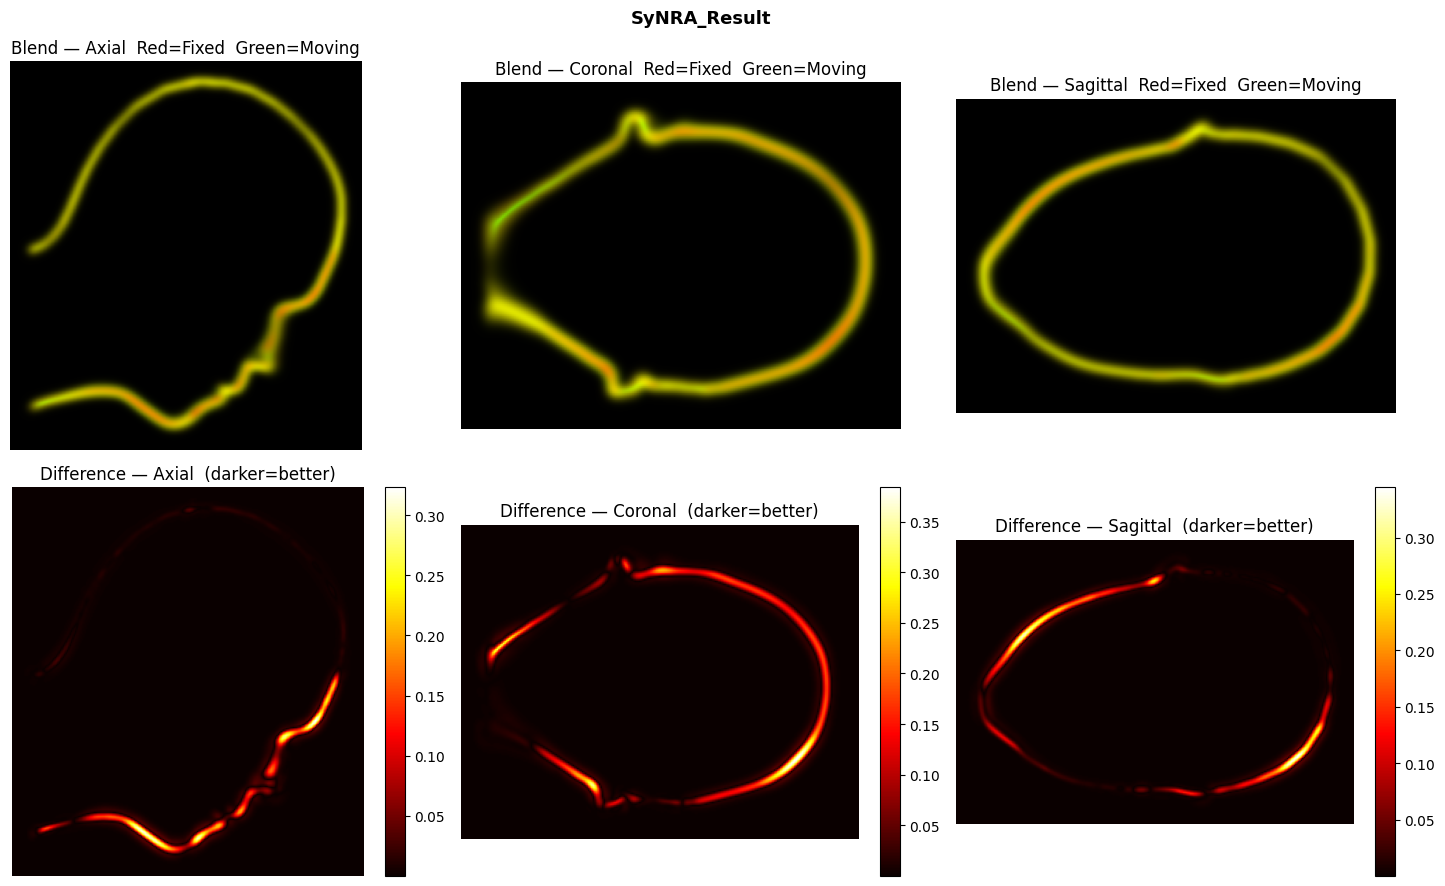

Saved -> /Users/lapastang/Downloads/case01/SyNRA_Result.png

Dice : 0.9886  (1.0 = perfect overlap)
IoU  : 0.9774
PASS -- excellent


In [31]:
def norm(a):
    a = a.astype(np.float32)
    return (a - a.min()) / (a.max() - a.min() + 1e-8)


def show_synra_result(fixed_ants, warped_ants, title='SyNRA_Result'):
    f_arr = norm(fixed_ants.numpy())
    m_arr = norm(warped_ants.numpy())
    z, y, x = [d//2 for d in f_arr.shape]
    views = [
        (f_arr[z,:,:], m_arr[z,:,:], 'Axial'),
        (f_arr[:,y,:], m_arr[:,y,:], 'Coronal'),
        (f_arr[:,:,x], m_arr[:,:,x], 'Sagittal'),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for col, (fs, ms, label) in enumerate(views):
        rgb = np.zeros((*fs.shape, 3), dtype=np.float32)
        rgb[...,0] = fs; rgb[...,1] = ms
        axes[0,col].imshow(rgb, origin='lower')
        axes[0,col].set_title(f'Blend — {label}  Red=Fixed  Green=Moving')
        axes[0,col].axis('off')
        diff = np.abs(fs - ms)
        im = axes[1,col].imshow(diff, cmap='hot', origin='lower')
        plt.colorbar(im, ax=axes[1,col], fraction=0.046)
        axes[1,col].set_title(f'Difference — {label}  (darker=better)')
        axes[1,col].axis('off')
    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, f'{title}.png')
    plt.savefig(out, dpi=120); plt.show()
    print(f'Saved -> {out}')


show_synra_result(fixed_ants, result['warpedmovout'])

# Dice + IoU
f_bin = (fixed_ants.numpy()  > 0.1).astype(np.float32)
m_bin = (result['warpedmovout'].numpy() > 0.1).astype(np.float32)
intersection = (f_bin * m_bin).sum()
dice = 2 * intersection / (f_bin.sum() + m_bin.sum() + 1e-8)
iou  = intersection / (np.clip(f_bin + m_bin, 0, 1).sum() + 1e-8)
print(f'\nDice : {dice:.4f}  (1.0 = perfect overlap)')
print(f'IoU  : {iou:.4f}')
if dice >= 0.85:   print('PASS -- excellent')
elif dice >= 0.70: print('MARGINAL -- try increasing reg_iterations or reducing flow_sigma')
else:              print('FAIL -- check scale_factor or mesh orientation')


## Cell 5 — Apply SyNRA Warp to Mesh Nodes → New `.vtu`

`ants.apply_transforms_to_points()` applies the full composite transform
(SyN warp field + affine matrix) directly to point coordinates.
All original cell/point/field data arrays are preserved via deep copy.
A `displacement_mm` array is added so you can colour the mesh in ParaView.


In [32]:
print(f'Applying SyNRA transform to {len(nodes_moving_norm):,} nodes...')
t0 = time.time()

# Apply full forward transform to normalized moving nodes
pts_df = pd.DataFrame(nodes_moving_norm, columns=['x','y','z'])

pts_warped_df = ants.apply_transforms_to_points(
    dim           = 3,
    points        = pts_df,
    transformlist = result['fwdtransforms'],
    whichtoinvert = [False] * len(result['fwdtransforms']),
)

nodes_reg_norm = pts_warped_df[['x','y','z']].values.astype(np.float64)
print(f'Done in {time.time()-t0:.2f}s')

# Undo normalization: unscale then restore original moving centroid
nodes_registered = (nodes_reg_norm / scale_factor) + c_moving

displacements = np.linalg.norm(nodes_registered - nodes_moving, axis=1)
print(f'\nDisplacement stats (original units):')
print(f'  Mean : {displacements.mean():.4f}')
print(f'  Max  : {displacements.max():.4f}')
print(f'  Std  : {displacements.std():.4f}')

# Deep copy — preserves all cell_data, point_data, field_data
registered_mesh = moving_mesh.copy(deep=True)
registered_mesh.points = nodes_registered
registered_mesh.point_data['displacement_mm'] = displacements.astype(np.float32)

out_vtu = os.path.join(OUTPUT_DIR, f'{stem}_synra_registered.vtu')
registered_mesh.save(out_vtu, binary=True)

fsize = os.path.getsize(out_vtu) / 1e6
print(f'\nSaved -> {out_vtu}  ({fsize:.1f} MB)')
print(f'  Points       : {registered_mesh.n_points:,}')
print(f'  Cells        : {registered_mesh.n_cells:,}')
print(f'  Point arrays : {list(registered_mesh.point_data.keys())}')

# Round-trip check
chk = pv.read(out_vtu)
err = np.max(np.abs(chk.points - nodes_registered))
print(f'\nRound-trip error : {err:.2e}  {"PASS" if err < 1e-6 else "WARN"}')


Applying SyNRA transform to 405,210 nodes...
Done in 0.70s

Displacement stats (original units):
  Mean : 1.1789
  Max  : 3.6726
  Std  : 0.5537

Saved -> /Users/lapastang/Downloads/case01/Head_V6_synra_registered.vtu  (22.0 MB)
  Points       : 405,210
  Cells        : 816,040
  Point arrays : ['Normals', 'Normals_Magnitude', 'displacement_mm']

Round-trip error : 0.00e+00  PASS


## Cell 6 — Final Validation + Output Summary

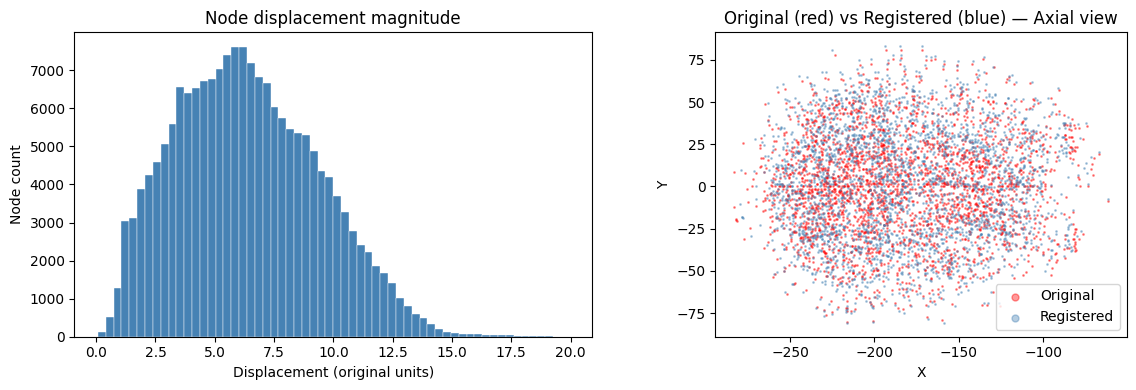

OUTPUT FILES:
  After_Affine_Refinement.png                          0.3 MB
  After_Center_Alignment.png                           0.3 MB
  After_Rigid_Registration.png                         0.3 MB
  Head_V6_synra_registered.vtu                         11.5 MB
  SyNRA_Result.png                                     0.5 MB
  ct_preprocessed.nii.gz                               7.2 MB
  ct_resampled.nii.gz                                  7.2 MB
  fixed_voxelized.nii.gz                               74.5 MB
  mesh_affine.nii.gz                                   259.0 MB
  mesh_center_aligned.nii.gz                           235.3 MB
  mesh_deformable_final.nii.gz                         12.7 MB
  mesh_preprocessed.nii.gz                             309.1 MB
  mesh_rigid.nii.gz                                    258.4 MB
  mesh_voxelized.nii.gz                                609.5 MB
  moving_voxelized.nii.gz                              73.6 MB
  moving_warped_synra.nii.gz              

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Displacement histogram
axes[0].hist(displacements, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Displacement (original units)')
axes[0].set_ylabel('Node count')
axes[0].set_title('Node displacement magnitude')

# Axial scatter: original vs registered
sample = np.random.choice(len(nodes_moving), min(3000, len(nodes_moving)), replace=False)
axes[1].scatter(nodes_moving[sample,0], nodes_moving[sample,1],
                s=1, c='red',  alpha=0.4, label='Original')
axes[1].scatter(nodes_registered[sample,0], nodes_registered[sample,1],
                s=1, c='steelblue', alpha=0.4, label='Registered')
axes[1].set_aspect('equal')
axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')
axes[1].set_title('Original (red) vs Registered (blue) — Axial view')
axes[1].legend(markerscale=5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'validation_displacement.png'), dpi=120)
plt.show()

# File list
print('=' * 60)
print('OUTPUT FILES:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    fsize = os.path.getsize(fpath) / 1e6
    print(f'  {fname:<52} {fsize:.1f} MB')
print('=' * 60)
print(f'\nKEY OUTPUT : {stem}_synra_registered.vtu')
print('  Open in ParaView alongside fixed_head.vtu')
print('  Colour by displacement_mm to visualise warp magnitude')


In [23]:
import vtk
import numpy as np

def diagnose_vtu_inputs(fixed_path, moving_path):
    """
    Diagnoses coordinate space mismatch between two .vtu files
    """
    def load_vtu(path):
        reader = vtk.vtkXMLUnstructuredGridReader()
        reader.SetFileName(path)
        reader.Update()
        mesh = reader.GetOutput()
        
        bounds = mesh.GetBounds()
        # bounds = (xmin, xmax, ymin, ymax, zmin, zmax)
        
        n_points = mesh.GetNumberOfPoints()
        pts = np.array([mesh.GetPoint(i) 
                        for i in range(min(n_points, 10000))])
        
        centre = pts.mean(axis=0)
        extent = np.array([
            bounds[1] - bounds[0],
            bounds[3] - bounds[2],
            bounds[5] - bounds[4]
        ])
        
        return {
            "bounds": bounds,
            "centre": centre,
            "extent": extent,
            "n_points": n_points
        }
    
    print("─── FIXED (head shape) ───────────────────")
    f = load_vtu(fixed_path)
    print(f"N points:  {f['n_points']}")
    print(f"Bounds:    {f['bounds']}")
    print(f"Centre:    {f['centre']}")
    print(f"Extent:    {f['extent']} units")
    
    print("\n─── MOVING (skull) ───────────────────────")
    m = load_vtu(moving_path)
    print(f"N points:  {m['n_points']}")
    print(f"Bounds:    {m['bounds']}")
    print(f"Centre:    {m['centre']}")
    print(f"Extent:    {m['extent']} units")
    
    print("\n─── MISMATCH DIAGNOSIS ───────────────────")
    com_distance = np.linalg.norm(f['centre'] - m['centre'])
    scale_ratio = f['extent'] / (m['extent'] + 1e-6)
    
    print(f"Centre distance: {com_distance:.1f} units")
    print(f"Scale ratio (fixed/moving): {scale_ratio}")
    
    if com_distance > 50:
        print("\n❌ TRANSLATION — centres far apart")
    if np.any(np.abs(scale_ratio - 1.0) > 0.3):
        print("\n❌ SCALE — volumes different sizes")
    if np.any(scale_ratio < 0):
        print("\n❌ FLIP — axis orientation mismatch")

diagnose_vtu_inputs(
    fixed_path="/Users/lapastang/Downloads/ImageToStl.com_head_voxels_transform.vtu",   # update path
    moving_path="/Users/lapastang/Downloads/Head_V6.vtu"  # update path
)

─── FIXED (head shape) ───────────────────
N points:  405210
Bounds:    (-0.5, 172.5, -0.5, 253.5, -0.5, 226.5)
Centre:    [  6.0839 147.9867 111.5533]
Extent:    [173. 254. 227.] units

─── MOVING (skull) ───────────────────────
N points:  179676
Bounds:    (-283.35641, -52.307373, -82.594749, 82.594749, 519.14178, 770.88989)
Centre:    [-182.11267967  -21.44043624  691.60771109]
Extent:    [231.049037 165.189498 251.74811 ] units

─── MISMATCH DIAGNOSIS ───────────────────
Centre distance: 632.9 units
Scale ratio (fixed/moving): [0.7487588  1.53762801 0.90169495]

❌ TRANSLATION — centres far apart

❌ SCALE — volumes different sizes
